In [ ]:
# Just an example to show how autoencoders can be used to detect anamolies

# Example 1 To Start

In [ ]:
# Tensorflow flow has inbuilt packages

import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense


In [ ]:
#Just Creating a Dummy Data

# Let’s assume:

# Each logistics record has 20 features
# (e.g., distance, fuel, time, weight, delays, etc.)

# Create dummy data: 1000 samples, 20 features
X_train = np.random.rand(1000, 20)
X_test = np.random.rand(200, 20)


In [ ]:
# Autoencoder

input_dim = 20

# Input layer
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(8, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Autoencoder model
autoencoder = Model(input_layer, decoded)

# Compile
autoencoder.compile(optimizer='adam', loss='mse')


In [ ]:
# Autoencoders are trained by giving X as both input and output

autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, X_test),
    verbose=1
)


In [ ]:
# for Reconstruction

# Reconstruct test data
X_reconstructed = autoencoder.predict(X_test)


In [ ]:
# Measure Reconstruction Error (Important!)

# This is how autoencoders are used for anomaly detection.

# Mean Squared Error per sample
reconstruction_error = np.mean(
    np.square(X_test - X_reconstructed),
    axis=1
)

print(reconstruction_error[:100])


# Low error → Normal data
# High error → Possible anomaly (e.g., abnormal shipment)

In [ ]:
# Simple Anomaly Threshold

threshold = np.percentile(reconstruction_error, 95)

anomalies = reconstruction_error > threshold
print("Number of anomalies detected:", np.sum(anomalies))



In [ ]:
# To know where the anamolies are actually present

anomalies = reconstruction_error > threshold
print(anomalies[:100])

anomaly_indices = np.where(anomalies)[0]
print("Anomaly indices:", anomaly_indices)


In [ ]:
# An interpretation

| Output            | Meaning                                |
| ----------------- | -------------------------------------- |
| `threshold`       | Max “normal” operational error         |
| `anomaly_indices` | Shipment / vehicle IDs                 |
| `anomaly values`  | Severity of abnormal behavior          |
| High error        | Delays, fraud, breakdown, inefficiency |


# Example 2 Industry Use Case: Autoencoder for Fleet Anomaly Detection

In [ ]:

Business problem: “We want to automatically detect abnormal truck trips that may indicate
fuel theft, breakdown risk, route deviation, or driver issues.”

# No labels available → Unsupervised learning needed

In [ ]:
# Typical Industry Data (What Companies Actually Have)

| Feature      | Meaning          |
| ------------ | ---------------- |
| distance_km  | Trip distance    |
| fuel_liters  | Fuel consumed    |
| trip_time_hr | Trip duration    |
| avg_speed    | Average speed    |
| idle_time    | Engine idle time |
| stops        | Number of stops  |
| load_weight  | Cargo weight     |
| delay_hr     | Delay vs plan    |


In [ ]:
# Simulated Industry Datase

import numpy as np
import pandas as pd

np.random.seed(42)

# Normal trips
normal_trips = np.random.normal(loc=[200, 40, 5, 60, 0.5, 2, 12, 0.2],
                                 scale=[20, 5, 1, 5, 0.2, 1, 2, 0.1],
                                 size=(950, 8))

# Abnormal trips (fuel theft, breakdowns)
abnormal_trips = np.random.normal(loc=[200, 70, 8, 40, 2, 6, 12, 3],
                                   scale=[30, 10, 2, 8, 1, 2, 3, 1],
                                   size=(50, 8))

data = np.vstack([normal_trips, abnormal_trips])
df = pd.DataFrame(data, columns=[
    "distance_km", "fuel_liters", "trip_time_hr", "avg_speed",
    "idle_time", "stops", "load_weight", "delay_hr"
])



In [ ]:
# Industry Reality – No Labels Used

*** We do NOT tell the model what is abnormal ****

In [ ]:
# Scale Data (Industry Best Practice)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df)


In [ ]:
# Autoencoder Model (Production-Style)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(4, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')


In [ ]:
# Train on Normal Behavior (Industry Trick)

autoencoder.fit(
    X_scaled, X_scaled,
    epochs=40,
    batch_size=32,
    verbose=0
)


In [ ]:
# Detect Anomalies

X_reconstructed = autoencoder.predict(X_scaled)

reconstruction_error = np.mean(
    np.square(X_scaled - X_reconstructed),
    axis=1
)

# print('reconstruction_error',reconstruction_error)
threshold = np.percentile(reconstruction_error, 95)
df["anomaly"] = reconstruction_error > threshold


In [ ]:
# Reconstruction Error =
# (distance error + fuel error + time error + speed error + idle error + …) / number of features


In [ ]:
# Results

print("Threshold:", threshold)
print("Anomalies detected:", df["anomaly"].sum())

df[df["anomaly"]].head()


In [ ]:
df["reconstruction_error"] = reconstruction_error

df[df["anomaly"]][
    ["distance_km", "fuel_liters", "trip_time_hr",
     "avg_speed", "idle_time", "stops",
     "load_weight", "delay_hr", "reconstruction_error"]
].head()


In [ ]:
| Feature      | Value | Why It Looks Odd           |
| ------------ | ----- | -------------------------- |
| distance_km  | 225   | Higher than average        |
| fuel_liters  | 36    | Low fuel for long distance |
| trip_time_hr | 5.44  | Slightly high              |
| avg_speed    | 63.8  | High                       |
| load_weight  | 5.5   | Very low load              |
| delay_hr     | 0.09  | Normal                     |


--------> Long distance
--------> Very low load
--------> Relatively low fuel
--------> High speed

In [ ]:
df[~df["anomaly"]].head() # just looking at data for comparsion

# “The model learned what a normal trip looks like.
# If a trip looks very different, it raises a red flag.”

# “No single feature. The joint behavior caused it.”

In [ ]:
Some Industry Usage Examples which i could think off.......

Fleet Management Companies
•	Fuel theft detection
•	Driver behavior monitoring
•	Early breakdown alerts
Warehousing
•	Abnormal picking times
•	Equipment failure detection
Supply Chain Risk
•	Delay pattern anomalies
•	Supplier performance issues


# Example 3 Real data

In [ ]:
# Which trips or driving segments behave abnormally compared to normal fleet operations?
(Unsupervised anomaly detection using autoencoders)

In [ ]:
# DT-CARGO

| File         | Level                | What it means ?       |
| ------------ | -------------------- | --------------------- |
| `fleet.csv`  | Vehicle level        | Truck specifications  |
| `tracks.csv` | Trip / segment level | Each driving segment  |
| `speed.csv`  | Sensor level (10 Hz) | Raw telematics stream |


In [ ]:
fleet.csv

Overview of the analyzed fleets
| Column                  | Data Type | Unit | Description                                                                                                 |
| ----------------------- | --------- | ---- | ----------------------------------------------------------------------------------------------------------- |
| vehicle_id              | int       | –    | Unique serial id of each vehicle                                                                            |
| fleet_test_id           | int       | –    | Unique serial id of the fleet the vehicle belongs to                                                        |
| gross_vehicle_weight    | int       | –    | Gross Vehicle Weight Rating (without trailer)                                                               |
| total_mass_with_trailer | int       | kg   | Gross Combination Weight Rating (with trailer; equals `gross_vehicle_weight` if no trailer can be attached) |
| axle_class              | int       | –    | Vehicle class according to [3]                                                                              |


In [ ]:
tracks.csv

Overview of track-wise measured and computed data

| Column            | Data Type   | Unit | Description                                                                        |
| ----------------- | ----------- | ---- | ---------------------------------------------------------------------------------- |
| track_id          | int         | –    | Unique serial id of each recorded track (ordered by `vehicle_id` and `start_time`) |
| vehicle_id        | int         | –    | Unique serial id of each vehicle                                                   |
| tour_id           | int         | –    | Serial id of each tour, assigned to 1..N tracks                                    |
| start_time        | timestamptz | –    | Start time of the recording with time zone at time of recording                    |
| stop_time         | timestamptz | –    | Stop time of the recording with time zone at time of recording                     |
| distance          | int         | m    | Distance driven during track                                                       |
| track_gap         | float       | m    | Distance gap to following track                                                    |
| avg_speed         | float       | m/s  | Average speed                                                                      |
| max_speed         | int         | m/s  | Maximum speed within track                                                         |
| n_signal_loss     | int         | –    | Number of signal loss events during recording                                      |
| d_signal_loss     | float       | m    | Distance covered during signal losses                                              |
| r_signal_loss     | float       | –    | Ratio of signal loss distance to recorded distance                                 |
| avg_hdop          | float       | m    | Average horizontal degree of precision during recording                            |
| home_base         | bool        | –    | End of recording is at home base of fleet operator                                 |
| long_haul         | bool        | –    | End of recording is more than 150 km away from home bases                          |
| rest_area         | bool        | –    | End of recording is at an unserviced rest area                                     |
| service_area_fuel | bool        | –    | End of recording is at a service area                                              |
| industrial_area   | bool        | –    | End of recording is in an industrial area                                          |
| cid               | int         | –    | Cluster id of last location in recording                                           |


In [ ]:
speed.csv

Speed and precision data (10 Hz sampling)

| Column | Data Type | Unit | Description                                              |
| ------ | --------- | ---- | -------------------------------------------------------- |
| epoch  | int       | s    | Unix timestamp of measurement (time zone: Europe/Berlin) |
| speed  | int       | m/s  | Speed at measurement                                     |
| hdop   | int       | m    | Horizontal degree of precision during recording [2]      |


In [ ]:
# lets start analyzing using tracks.csv

# In tracks.csv, i had intentionally taken only numeric + meaningful operational features:

# Exclude:
#     IDs
#     timestamps
#     location cluster IDs

In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

tracks = pd.read_csv("/content/tracks.csv")

features = [
    "distance",
    "avg_speed",
    "max_speed",
    "track_gap",
    "n_signal_loss",
    "d_signal_loss",
    "r_signal_loss",
    "avg_hdop"
]

X = tracks[features].fillna(0)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# Autoencoder

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(4, activation="relu")(input_layer)
decoded = Dense(input_dim, activation="linear")(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer="adam", loss="mse")


In [ ]:
# Training

autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=40,
    batch_size=64,
    shuffle=True,
    verbose=1
)

Epoch 1/40
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0023
Epoch 2/40
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 5.0037e-04
Epoch 3/40
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 3.6573e-04
Epoch 4/40
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.1396e-04
Epoch 5/40
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.0358e-04
Epoch 6/40
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.0237e-04
Epoch 7/40
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.0172e-04
Epoch 8/40
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.0111e-04
Epoch 9/40
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.0054e-04
Epoch 10/40
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.0018e-04
Epoch 11/40
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 9.9778e-05
Epoch 12/40
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 9.5892e-05
Epoch 13/40
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 7.1570e-05
Epoch 14/40
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/s

In [ ]:
# Detecting Anomalies (Core Industry Logic)

import numpy as np

X_recon = autoencoder.predict(X_scaled)

reconstruction_error = np.mean(
    np.square(X_scaled - X_recon),
    axis=1
)

threshold = np.percentile(reconstruction_error, 95)

tracks["reconstruction_error"] = reconstruction_error
tracks["anomaly"] = reconstruction_error > threshold

3183/3183 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [ ]:
# Interpreting Anomalies
tracks[tracks["anomaly"]][
    ["track_id", "vehicle_id", "distance", "avg_speed",
     "n_signal_loss", "r_signal_loss", "avg_hdop",
     "reconstruction_error"]
].head()


# their reconstruction_error > anomaly_threshold

,track_id,vehicle_id,distance,avg_speed,n_signal_loss,r_signal_loss,avg_hdop,reconstruction_error
123,123,1,319206.0,20.69,5.0,0.000617,0.723745,0.000274
124,124,1,262916.0,18.19,8.0,0.000422,0.624387,0.000194
129,129,1,193623.0,16.60,4.0,0.000031,0.523357,0.000113
135,135,1,329210.0,20.68,5.0,0.000844,0.554791,0.000279
137,137,1,87181.0,17.29,5.0,0.001101,0.508563,0.000023


In [ ]:
# 124
| Observation         |
| ------------------- |
| Very long distance  |
| Even lower speed    |
| **8 signal losses** |
| High HDOP           |
-------------------------------------------> Possibly urban congestion, tunnel-heavy route, or telemetry instability.
# 129
| Observation           |
| --------------------- |
| Medium-long distance  |
| Low speed             |
| Almost no signal loss |
| Very clean GPS        |

------------------------------------------->Because:
                                                Distance + speed combination is uncommon
                                                The model expects either shorter distance or higher speed

In [ ]:
# feature-wise reconstruction error:

import pandas as pd
import numpy as np

recon_df = pd.DataFrame(
    np.square(X_scaled - X_recon),
    columns=features
)

recon_df.loc[tracks["anomaly"]].mean()

# Notice that  signal loss, avg_speed, hdop Contributes most to error. [their reconstruction error is high]

distance         1.534742e-05
avg_speed        5.626208e-04
max_speed        4.719538e-06
track_gap        2.792484e-06
n_signal_loss    3.345098e-03
d_signal_loss    3.997180e-03
r_signal_loss    1.992098e-04
avg_hdop         7.066180e-07
dtype: float64

## Using fleet.csv for  Anomalies detection

In [ ]:
import pandas as pd

fleet = pd.read_csv("/content/fleet.csv")

# Merge vehicle-level info into track-level data
tracks_merged = tracks.merge(
    fleet,
    on="vehicle_id",
    how="left"
)


# Now each track knows:

#     Vehicle weight
#     Axle class
#     Trailer configuration

In [ ]:
tracks_merged.columns


Index(['track_id', 'vehicle_id', 'tour_id', 'start_time', 'stop_time',
       'distance', 'track_gap', 'avg_speed', 'max_speed', 'n_signal_loss',
       'd_signal_loss', 'r_signal_loss', 'avg_hdop', 'home_base', 'long_haul',
       'rest_area', 'service_area_fuel', 'industrial_area', 'cid',
       'reconstruction_error', 'anomaly', 'fleet_test_id',
       'gross_vehicle_weight', 'total_mass_with_trailer', 'axle_class'],
      dtype='object')

In [ ]:
# Analyze Anomalies by Vehicle Characteristics
## A) Are heavier vehicles more anomalous?

tracks_merged.groupby("axle_class")["anomaly"].mean()



axle_class
9     0.022038
12    0.020895
41    0.036813
42    0.074348
97    0.015420
98    0.048084
Name: anomaly, dtype: float64

In [ ]:
# B) Does trailer weight matter?
tracks_merged.groupby("total_mass_with_trailer")["anomaly"].mean()


total_mass_with_trailer
26000    0.022038
32000    0.017823
40000    0.055420
Name: anomaly, dtype: float64

In [ ]:
# C) Vehicle-wise anomaly count
tracks_merged.groupby("vehicle_id")["anomaly"].sum().sort_values(ascending=False)

vehicle_id
21    224
26    217
12    213
2     211
22    193
6     191
36    179
50    163
16    163
23    150
45    150
49    142
43    139
44    131
52    131
47    129
1     128
48    122
27    122
24    121
13    115
41    113
51    110
46    105
28    105
53    102
10     99
39     98
18     96
38     93
20     90
11     87
31     85
3      78
19     58
17     52
40     50
7      45
35     43
4      41
42     31
29     29
5      25
30     23
14     23
15     19
32     15
9      13
33     11
25     10
37      9
8       0
34      0
Name: anomaly, dtype: int64

# “Which vehicles should I inspect first?”
<!--
Vehicle 21 generated 224 track segments
Those segments behaved very differently from normal fleet behavior
More than any other vehicle in the fleet -->

<!-- How Industry Interprets This  
Step 1: Prioritization  
“Vehicle 21 deserves priority review.”

Step 2: Ask the Right Business Questions
For vehicle 21, operators would check:
Vehicle-related
•	GPS antenna or sensor issues?
•	Telematics hardware malfunction?
•	Vehicle class or configuration mismatch?
Route-related
•	Assigned to tunnel-heavy or urban routes?
•	Poor satellite coverage areas?
•	Frequent depots or industrial zones?
Driver-related
•	Same driver or multiple?
•	Aggressive / stop-go driving patterns?
 -->


## Remember we had SPEED.csv? It contains speed measurements at 10 Hz (10 readings per second)

In [ ]:

# Why Use speed.csv ?
# •	Detect abnormal driving: harsh braking, over-speeding, stop-and-go
# •	Detect sensor errors: spikes, signal loss
# •	Find driver behavior anomalies
# •	Feed into sequence autoencoders (LSTM/CNN)

In [ ]:
import pandas as pd
import numpy as np

import pandas as pd

path = r"/content/Speed.csv"   # Use raw string for Windows paths
speed_df = pd.read_csv(path)
speed_values = speed_df["speed"].values



In [ ]:
# Step B: Convert to sequences

# Sequence length = 100 readings (~10 seconds)
# Each sequence = one “sample” for the autoencoder

def create_sequences(data, seq_len=100):
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i:i+seq_len])
    return np.array(sequences)

X_seq = create_sequences(speed_values, seq_len=100)
X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))  # for LSTM


In [ ]:
# LSTM Autoencoder (Pattern Learning)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

timesteps = X_seq.shape[1]

input_layer = Input(shape=(timesteps,1))
encoded = LSTM(32, activation="relu")(input_layer)
decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(32, activation="relu", return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(1))(decoded)

lstm_autoencoder = Model(input_layer, decoded)
lstm_autoencoder.compile(optimizer="adam", loss="mse")


In [ ]:
# Train on Normal Driving Behavior

lstm_autoencoder.fit(
    X_seq, X_seq,
    epochs=20,
    batch_size=64,
    shuffle=True,
    verbose=1
)
## “We are teaching the model what normal driving patterns look like — speed changes over time.”

Epoch 1/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 20s 87ms/step - loss: 34606673920.0000
Epoch 2/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 189.9278 
Epoch 3/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 963171.5625
Epoch 4/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 158.3442
Epoch 5/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - loss: 148.0721
Epoch 6/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - loss: 137.2862
Epoch 7/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - loss: 130.7813
Epoch 8/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - loss: 172.0243 
Epoch 9/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 461.3522
Epoch 10/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 372.2982
Epoch 11/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - loss: 103.6604
Epoch 12/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 97.5850
Epoch 13/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - loss: 99.3394
Epoch 14/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 94.627

In [ ]:
X_recon = lstm_autoencoder.predict(X_seq)

reconstruction_error = np.mean(
    np.square(X_seq - X_recon),
    axis=(1,2)
)

threshold = np.percentile(reconstruction_error, 95)
anomalous_sequences = reconstruction_error > threshold

# True = abnormal sequence
# Map back to time in track to locate problems

228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step


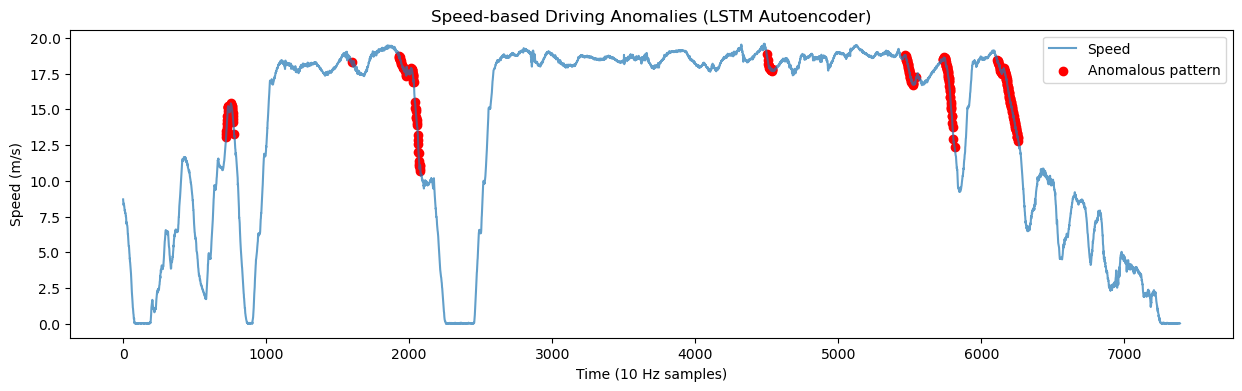

In [ ]:
# Compute window center indices
seq_len = 100
num_windows = len(speed_values) - seq_len

len(anomalous_sequences), num_windows

window_centers = np.arange(num_windows) + seq_len // 2
anomaly_x = window_centers[anomalous_sequences]
anomaly_y = speed_values[anomaly_x]


import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
plt.plot(speed_values, label="Speed", alpha=0.7)
plt.scatter(anomaly_x, anomaly_y, color="red", label="Anomalous pattern")

plt.xlabel("Time (10 Hz samples)")
plt.ylabel("Speed (m/s)")
plt.title("Speed-based Driving Anomalies (LSTM Autoencoder)")
plt.legend()
plt.show()


# The autoencoder does NOT say “high speed = anomaly”.
# It says: “this speed pattern over time looks unusual compared to normal driving.”

<!-- # What “Normal” Means Here
# When you trained the autoencoder, you did this:
#     lstm_autoencoder.fit(X_seq, X_seq)
# That means:
# •	The model sees thousands of 10-second speed patterns
# •	It learns:
#     o	How trucks usually accelerate
#     o	How they cruise
#     o	How they slow down
# •	These patterns become “normal behavior”
 -->

# Example 4 # T-Drive taxi trajectory dataset (Microsoft)


In [ ]:

This dataset is:
•	10,357 vehicles
•	1 week of operations
•	15 million GPS points
•	9 million km of movement

A large-scale urban transportation system with repeated routes, traffic patterns, and driver behaviors.


Why Autoencoders Are a Perfect Fit Here ?

Constraints in this data ----->
•	No labels saying “this trip is bad”
•	No rule that defines “wrong route”
But:
•	Massive repetition of normal behavior

This is exactly where autoencoders shine.

Autoencoders learn what normally happens, then flag what deviates.


In [ ]:
# Use Case 1: Route Deviation Detection
# Use Case 2: Traffic Pattern Learning
# Use Case 3: Driver / Vehicle Behavior Profiling
# Use Case 4: Urban Logistics Zone Detection
# Use Case 5: GPS Noise & Data Quality Control

In [ ]:
What an Autoencoder is ACTUALLY Learning Here ?

This is critical for understanding.
It is NOT learning:
                “Good vs bad taxi”
It IS learning:
            Typical spatio-temporal movement patterns

Examples:
•	Typical turning angles
•	Typical speed changes
•	Typical stop durations
•	Typical route geometry

An anomaly means:
“This trip does not look like most trips we have seen before.”


In [ ]:
# lets try this Route Deviation Detection..............

“Did this vehicle follow the usual route, or did it take an unusual detour?” Then which driver had did it ?

We will teach an autoencoder what a normal trip trajectory looks like.
    If a trip cannot be reconstructed well → it is unusual.

In [ ]:
# the data has 10357 txt files... so (i had removed around 5000 data intentionally)

One file ≈ one taxi
One file = many trips mixed together
We must segment trips ourselves

In [3]:
!unzip /content/taxi_log_2008_by_id.zip -d /content/taxi_data


Archive:  /content/taxi_log_2008_by_id.zip
   creating: /content/taxi_data/taxi_log_2008_by_id/
  inflating: /content/taxi_data/taxi_log_2008_by_id/10190.txt  
  inflating: /content/taxi_data/taxi_log_2008_by_id/10191.txt  
  inflating: /content/taxi_data/taxi_log_2008_by_id/10192.txt  
  inflating: /content/taxi_data/taxi_log_2008_by_id/10193.txt  
  inflating: /content/taxi_data/taxi_log_2008_by_id/10194.txt  
  inflating: /content/taxi_data/taxi_log_2008_by_id/10195.txt  
  inflating: /content/taxi_data/taxi_log_2008_by_id/10196.txt  


In [4]:
import os
import pandas as pd

DATA_DIR = "/content/taxi_data/taxi_log_2008_by_id"   # folder with 10357 txt files

all_trips = []

for file in os.listdir(DATA_DIR):
    if file.endswith(".txt"):
        path = os.path.join(DATA_DIR, file)
        df = pd.read_csv(
            path,
            names=["taxi_id", "time", "lon", "lat"]
        )
        df["time"] = pd.to_datetime(df["time"])
        all_trips.append(df)

data = pd.concat(all_trips, ignore_index=True)


In [ ]:
# Step 2: Sort and Clean (MANDATORY)

data = data.sort_values(["taxi_id", "time"])
data = data.dropna()


In [ ]:
# Step 3: Trip Segmentation

# T-Drive does not give trip IDs.
# Industry rule:
# If time gap > 5 minutes → new trip

data["time_diff"] = data.groupby("taxi_id")["time"].diff().dt.total_seconds()

data["new_trip"] = (data["time_diff"] > 300) | (data["time_diff"].isna())

data["trip_id"] = data.groupby("taxi_id")["new_trip"].cumsum()


In [ ]:
# Step 4: Create Movement Feature

data["d_lon"] = data.groupby(["taxi_id","trip_id"])["lon"].diff().fillna(0)
data["d_lat"] = data.groupby(["taxi_id","trip_id"])["lat"].diff().fillna(0)


In [ ]:
# Step 5: Build Sequences
def make_sequences(df, seq_len=50):
    sequences = []
    for (_, _), trip in df.groupby(["taxi_id", "trip_id"]):
        values = trip[["d_lon", "d_lat"]].values
        if len(values) > seq_len:
            for i in range(len(values) - seq_len):
                sequences.append(values[i:i+seq_len])
    return np.array(sequences)

X_seq = make_sequences(data, seq_len=50)

## This creates hundreds of thousands of route segments.

In [ ]:
# Step 6: Train Autoencoder (Fleet-Level) # THIS WILL TAKE TIME................. IT STARTED AFTER 20 MIN

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

inp = Input(shape=(50,2))
encoded = LSTM(64, activation="relu")(inp)
decoded = RepeatVector(50)(encoded)
decoded = LSTM(64, activation="relu", return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(2))(decoded)

autoencoder = Model(inp, decoded)
autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.fit(X_seq, X_seq, epochs=5, batch_size=128, shuffle=True)


Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - loss: 2.4045  
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - loss: 0.9024    
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - loss: 0.9058    
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.9049
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - loss: 0.9535    


In [ ]:
# Step 7: Detect Route Deviations

X_recon = autoencoder.predict(X_seq)

recon_error = np.mean((X_seq - X_recon)**2, axis=(1,2))
threshold = np.percentile(recon_error, 95)

anomalous_routes = recon_error > threshold
anomalous_routes

110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


array([False, False, False, ..., False, False, False], shape=(3517,))

In [ ]:
# Each taxi generates thousands of normal route segments.
# The model learns these normal movement patterns.
# Segments that don’t fit are flagged as route deviations

In [ ]:
# Step 8: To detect which driver had changed

### Count deviations per driver
from collections import defaultdict

driver_stats = defaultdict(lambda: {"total": 0, "deviations": 0})

for i, (taxi_id, trip_id, _) in enumerate(index_map):
    driver_stats[taxi_id]["total"] += 1
    if anomalous_routes[i]:
        driver_stats[taxi_id]["deviations"] += 1


In [ ]:
# Creating a Driver-Level Table

driver_df = pd.DataFrame([
    {
        "taxi_id": taxi,
        "total_segments": stats["total"],
        "deviated_segments": stats["deviations"],
        "deviation_rate": stats["deviations"] / stats["total"]
    }
    for taxi, stats in driver_stats.items()
])


In [ ]:
driver_df.sort_values("deviation_rate", ascending=False).head(10)

,taxi_id,total_segments,deviated_segments,deviation_rate
0,10191,1003,78,0.077767
2,10195,1087,51,0.046918
1,10193,1427,47,0.032936


# Example 5 SUPPLY CHAIN FOR BIG DATA ANALYSIS

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ---- Load structured data ----
df_struct = pd.read_csv('/content/DataCoSupplyChainDataset.csv', nrows=50, encoding='ISO-8859-1')

# # Intentionally took 5 features
features = ['Days for shipping (real)',
            'Days for shipment (scheduled)',
            'Sales per customer',
            'Benefit per order',
            'Late_delivery_risk']

data_struct = df_struct[features].fillna(0)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_struct)

input_dim = data_scaled.shape[1]
latent_dim = 4

# ---- VAE as subclassed model ----
class VAE(Model):
    def __init__(self, input_dim, latent_dim):
        super(VAE, self).__init__()
        # Encoder
        self.encoder_dense = layers.Dense(32, activation='relu')
        self.z_mean = layers.Dense(latent_dim)
        self.z_log_var = layers.Dense(latent_dim)
        # Decoder
        self.decoder_dense = layers.Dense(32, activation='relu')
        self.decoder_output = layers.Dense(input_dim)

    def encode(self, x):
        h = self.encoder_dense(x)
        return self.z_mean(h), self.z_log_var(h)

    def reparameterize(self, mean, logvar):
        eps = tf.random.normal(shape=tf.shape(mean))
        return mean + tf.exp(0.5 * logvar) * eps

    def decode(self, z):
        h = self.decoder_dense(z)
        return self.decoder_output(h)

    def call(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterize(mean, logvar)
        x_recon = self.decode(z)
        # Loss
        recon_loss = tf.reduce_mean(tf.square(x - x_recon))
        kl_loss = -0.5 * tf.reduce_mean(1 + logvar - tf.square(mean) - tf.exp(logvar))
        self.add_loss(recon_loss + kl_loss)
        return x_recon

# ---- Compile & Train ----
vae = VAE(input_dim, latent_dim)
vae.compile(optimizer='adam')
vae.fit(data_scaled, data_scaled, epochs=30, batch_size=32, validation_split=0.1)

# ---- Extract Latent Features ----
z_mean_layer, z_logvar_layer = vae.encode(tf.convert_to_tensor(data_scaled, dtype=tf.float32))
z_latent = vae.reparameterize(z_mean_layer, z_logvar_layer)
print("Latent shape:", z_latent.shape)

Epoch 1/30


<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
C:\Users\fedex\AppData\Local\Temp\ipykernel_33708\3903459796.py:7: SyntaxWarning: invalid escape sequence '\D'
  df_struct = pd.read_csv('Dataset\Datacod\DataCoSupplyChainDataset.csv', nrows=50, encoding='ISO-8859-1')


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 316ms/step - loss: 1.4508 - val_loss: 2.2509
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 1.2703 - val_loss: 1.8914
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 1.4248 - val_loss: 2.1120
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 1.1896 - val_loss: 2.3596
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 1.2552 - val_loss: 2.3780
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 1.1950 - val_loss: 2.5869
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 1.1108 - val_loss: 2.3165
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 1.0780 - val_loss: 1.9386
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 1.1464 - val_loss: 2.7914
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 1.1638 - val_loss: 2.0225
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 1.1979 - val_loss: 2.3467
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.9899 - val_loss: 2.3686


In [ ]:
print("Total rows:", df.shape[0])
print(df_struct.shape)


Total rows: 1120
(100, 53)


# Now that latent space is ready, lets see what all we can do

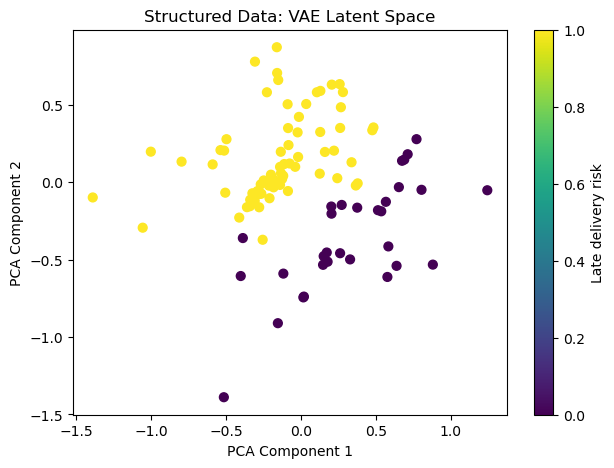

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import tensorflow as tf

# Convert data_scaled to tf.Tensor
data_tensor = tf.convert_to_tensor(data_scaled, dtype=tf.float32)

# Use the VAE encoder to get mean and log variance
z_mean_layer, z_logvar_layer = vae.encode(data_tensor)

# Use z_mean for visualization (latent representation)
z_mean_np = z_mean_layer.numpy()  # convert to numpy for PCA

# Optional: reduce to 2D with PCA for plotting
pca = PCA(n_components=2)
z_2d = pca.fit_transform(z_mean_np)

# Plot latent space colored by 'Late_delivery_risk'
plt.figure(figsize=(7,5))
plt.scatter(z_2d[:,0], z_2d[:,1], c=data_struct['Late_delivery_risk'], cmap='viridis', s=40)
plt.colorbar(label='Late delivery risk')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Structured Data: VAE Latent Space")
plt.show()


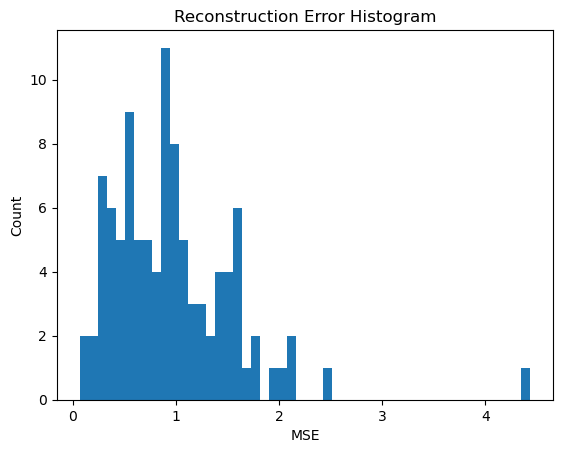

Top anomalous shipments (indices): [40 28 59  2 19  1  5 75 15 34]
    Days for shipping (real)  Days for shipment (scheduled)  \
40                         1                              0   
28                         3                              4   
59                         2                              2   
2                          4                              4   
19                         0                              0   
1                          5                              4   
5                          6                              4   
75                         5                              2   
15                         2                              1   
34                         2                              1   

    Sales per customer  Benefit per order  Late_delivery_risk  
40          298.250000         143.160004                   1  
28          272.029999         -17.139999                   0  
59          263.970001        -184.779999      

In [ ]:
# Detect Anomalies (Deviation Detection)
# High reconstruction error → unusual or suspicious shipments.

# Get reconstructed outputs
reconstructed = vae(data_tensor).numpy()

# Compute reconstruction error per shipment
recon_error = np.mean((data_scaled - reconstructed)**2, axis=1)

# Visualize
plt.hist(recon_error, bins=50)
plt.title("Reconstruction Error Histogram")
plt.xlabel("MSE")
plt.ylabel("Count")
plt.show()

# Flag top anomalies
anomalies_idx = np.argsort(recon_error)[-10:]  # top 10 unusual shipments
print("Top anomalous shipments (indices):", anomalies_idx)
print(data_struct.iloc[anomalies_idx])


In [ ]:
# Extract Latent Features
# The encoder compresses each shipment’s features into a low-dimensional latent vector, which can be used for:

#     Clustering similar shipments (e.g., same delivery patterns)
#     Feeding into predictive models (e.g., late delivery classification)
#     Visualizing operational patterns

# Convert input to tensor
data_tensor = tf.convert_to_tensor(data_scaled, dtype=tf.float32)

# Get latent features
z_mean_layer, z_logvar_layer = vae.encode(data_tensor)
latent_features = z_mean_layer.numpy()  # shape: (1000, latent_dim)

C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


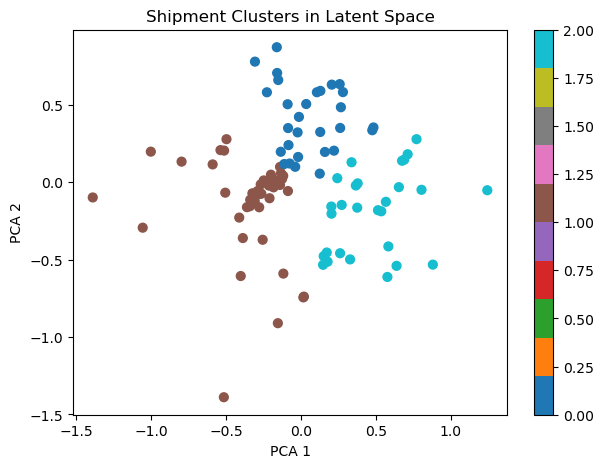

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# -------------------------
# Clustering
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(latent_features)

# PCA for visualization
pca = PCA(n_components=2)
z_2d = pca.fit_transform(latent_features)

plt.figure(figsize=(7,5))
plt.scatter(z_2d[:,0], z_2d[:,1], c=clusters, cmap='tab10', s=40)
plt.colorbar()
plt.title("Shipment Clusters in Latent Space")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# How shipments are organized by the model based on their operational behavior

# Cluster A → fast delivery, low risk
# Cluster B → slow delivery, high risk
# Cluster C → high sales but frequent delays

In [ ]:
# Separate label for predictive model
y = data_struct['Late_delivery_risk'].astype(int)  # binary or categorical
X = data_struct.drop('Late_delivery_risk', axis=1)


# -------------------------
# 5) Predictive Model
# -------------------------
# Use latent features as input to classifier
X_train, X_test, y_train, y_test = train_test_split(latent_features, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Classification Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Classification Accuracy: 0.95

Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      0.93      0.96        14

    accuracy                           0.95        20
   macro avg       0.93      0.96      0.94        20
weighted avg       0.96      0.95      0.95        20



# Assignment RUN VAE on 1120 rows

In [ ]:
1. Anomaly Detection
Autoencoders learn “normal” patterns. When they fail to reconstruct data well, it signals an anomaly.
Applications:
•	Detecting fraudulent shipments
•	Identifying abnormal delivery times
•	Spotting sensor malfunctions in vehicles or warehouses
•	Detecting unusual fuel consumption in fleets
Example:
If a truck normally uses 20–25 liters per route and suddenly uses 45, an autoencoder flags it as abnormal.
________________________________________
2. Demand Forecasting Support
Autoencoders are often used as a preprocessing step for forecasting models.
Applications:
•	Extracting key demand patterns from historical sales data
•	Removing noise before time-series forecasting
•	Learning seasonality and hidden demand drivers
Example:
An autoencoder compresses hundreds of product–store–time features into a compact representation fed into an LSTM or XGBoost model.
________________________________________
3. Route Optimization & Traffic Pattern Learning
Autoencoders can learn compressed representations of complex route and traffic data.
Applications:
•	Identifying hidden traffic patterns
•	Learning road congestion behavior
•	Supporting dynamic routing decisions
Example:
Encoded GPS trajectories help clustering routes with similar congestion profiles.
________________________________________
4. Warehouse Operations Optimization
Warehouses generate massive sensor and operational data.
Applications:
•	Identifying inefficient picking paths
•	Detecting abnormal storage behavior
•	Optimizing inventory placement
Example:
Autoencoders detect unusual movement patterns indicating layout inefficiencies or worker fatigue.
________________________________________
5. Predictive Maintenance
s.
Applications:
•	Predicting failures in trucks, forklifts, conveyors
•	Monitoring engine, temperature, vibration sensors
Example:
An autoencoder trained on normal machine behavior flags early signs of breakdown before failure occurs.
________________________________________
6. Inventory Management & Stock Anomalies
Autoencoders detect unusual inventory behavior.
Applications:
•	Identifying overstocking or stock leakage
•	Detecting mismatches between physical and system inventory
•	Spotting supplier inconsistencies
Example:
Sudden unexplained inventory drops trigger investigation.
________________________________________
7. Customer Behavior & Order Pattern Analysis
Autoencoders help learn latent customer patterns.
Applications:
•	Customer segmentation
•	Detecting abnormal ordering behavior
•	Identifying churn signals
Example:
A sudden change in ordering frequency or size is detected as an anomaly.
________________________________________
8. Data Compression & Integration
Logistics systems pull data from many sources.
Applications:
•	Compressing high-volume IoT data
•	Integrating heterogeneous data (ERP, WMS, TMS)
•	Reducing storage and transmission costs
Example:
Sensor data compressed by autoencoders before cloud transmission.
________________________________________
9. Risk & Disruption Detection
Autoencoders identify early signals of supply chain disruptions.
Applications:
•	Detecting abnormal lead times
•	Identifying supplier reliability issues
•	Spotting port or customs delays
Example:
Encoded patterns reveal unusual delay clusters across regions.
________________________________________
10. Sustainability & Cost Optimization
Autoencoders can help optimize environmental impact.
Applications:
•	Detecting fuel inefficiency
•	Monitoring CO₂ emission anomalies
•	Supporting green routing decisions
________________________________________
Types of Autoencoders Commonly Used in Logistics

•	Denoising Autoencoders – noisy sensor data
•	Variational Autoencoders (VAEs) – scenario simulation, demand modeling
•	Sparse Autoencoders – feature selection
•	LSTM Autoencoders – time-series logistics data
•	Convolutional Autoencoders – image/video data (warehouse cameras)

